# Taylor Approximations and First-Order Necessary Conditions
### MECH 559 - Systems Optimization - L05

This notebook rebuilds the Taylor-series and stationary-point material from the lecture computationally: how a Taylor polynomial approximates a function (and why more terms is not always better), how the first-order necessary condition (FONC) is derived, and how to find and classify stationary points in one and two variables.

## Learning objectives

By the end, students should be able to:

1. Build Taylor polynomial approximations of increasing order around a point and explain when they do (and do not) improve the approximation.
2. State the univariate and multivariate first-order necessary condition and recognize a stationary point.
3. Find stationary points of a nonlinear function numerically by solving $\nabla f(x)=0$.
4. Recognize a saddle point: a stationary point that is neither a minimizer nor a maximizer.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq, fsolve

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. Taylor's theorem, applied to a tricky function

Taylor's theorem: a function centered on $x^\ast$ can be approximated as

$$
f(x) \approx f(x^\ast) + f'(x^\ast)(x-x^\ast) + \frac{f''(x^\ast)}{2!}(x-x^\ast)^2 + \cdots + \frac{f^{(k)}(x^\ast)}{k!}(x-x^\ast)^k.
$$

We use the same example as the slides, $f(x) = \dfrac{1}{1+x^2}$, expanded about $x^\ast=0$. Because $\dfrac{1}{1+x^2}=\dfrac{1}{1-(-x^2)}$ is a geometric series in $u=-x^2$,

$$
f(x) = \sum_{n=0}^{\infty} (-1)^n x^{2n} = 1 - x^2 + x^4 - x^6 + \cdots, \qquad |x| < 1,
$$

so its Maclaurin (Taylor-at-0) polynomial of order $k$ is just the partial sum up to $x^k$ - computed below directly from this closed form rather than by (numerically fragile) high-order finite differences.

> **Predict:** the series above only converges for $|x|<1$. What do you expect the $k=10$ approximation to do at $x=1.5$ - get closer to $f(1.5)$, or farther away - as $k$ increases?

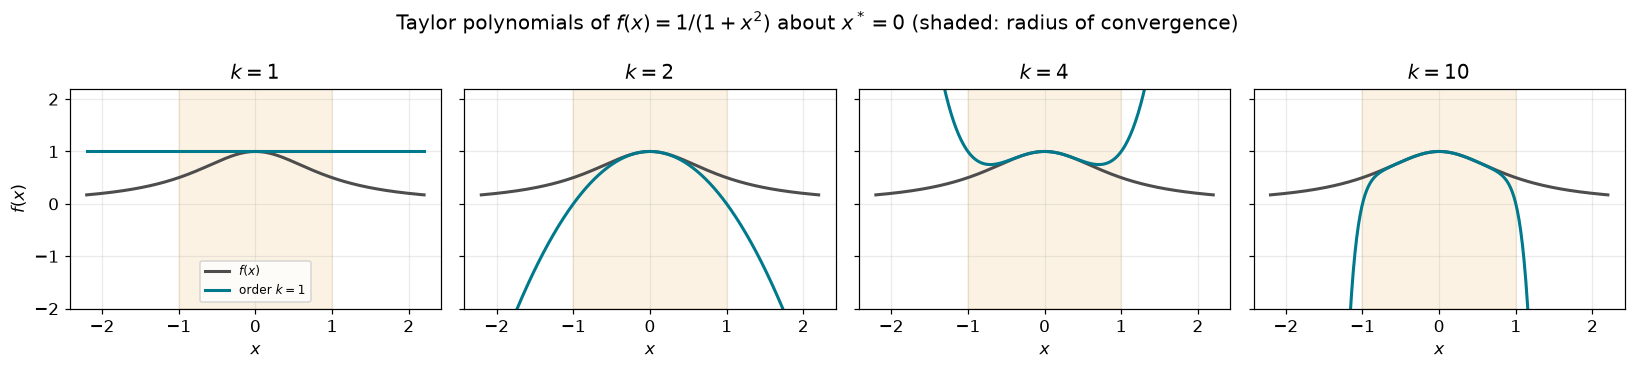

k= 1: T_k(1.5) =      1.000   true f(1.5) = 0.308   |error| =      0.692
k= 2: T_k(1.5) =     -1.250   true f(1.5) = 0.308   |error| =      1.558
k= 4: T_k(1.5) =      3.812   true f(1.5) = 0.308   |error| =      3.505
k=10: T_k(1.5) =    -39.614   true f(1.5) = 0.308   |error| =     39.922

Outside |x|<1 the error grows with k: more terms make a WORSE global approximation here.


In [3]:
def runge(x):
    return 1 / (1 + x**2)

def taylor_runge(x, k):
    # Maclaurin polynomial of f(x)=1/(1+x^2), truncated at order k (only even powers appear).
    total = np.zeros_like(x, dtype=float)
    n = 0
    while 2 * n <= k:
        total = total + (-1)**n * x**(2 * n)
        n += 1
    return total

xx = np.linspace(-2.2, 2.2, 400)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, k in zip(axes, [1, 2, 4, 10]):
    ax.plot(xx, runge(xx), color="0.3", lw=2, label="$f(x)$")
    ax.plot(xx, taylor_runge(xx, k), color=COLORS["boundary"], lw=2, label=f"order $k={k}$")
    ax.axvspan(-1, 1, color=COLORS["accent"], alpha=0.15)
    ax.set_ylim(-2, 2.2)
    ax.set_title(f"$k={k}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
axes[0].legend(fontsize=8, loc="lower center")
plt.suptitle("Taylor polynomials of $f(x)=1/(1+x^2)$ about $x^*=0$ (shaded: radius of convergence)")
plt.tight_layout()
plt.show()

for k in [1, 2, 4, 10]:
    approx = taylor_runge(np.array([1.5]), k)[0]
    print(f"k={k:2d}: T_k(1.5) = {approx:10.3f}   true f(1.5) = {runge(1.5):.3f}   |error| = {abs(approx-runge(1.5)):10.3f}")
print()
print("Outside |x|<1 the error grows with k: more terms make a WORSE global approximation here.")

---
## 2. First-order local approximation and the univariate FONC

Keeping only the linear term gives the tangent-line approximation

$$
f(x) \approx f(x^\ast) + f'(x^\ast)(x-x^\ast).
$$

For $x^\ast$ to be a local minimizer we need $f(x)\ge f(x^\ast)$ for all $x$ near $x^\ast$, and plugging in the tangent-line approximation forces

$$
f'(x^\ast) = 0
$$

(the *first-order necessary condition*, FONC) - because otherwise the sign of the right-hand side flips with the sign of $(x-x^\ast)$, and the inequality cannot hold on both sides of $x^\ast$.

We revisit $f(x)=1/(1+x^2)$: its slope at $x^\ast=0$ is zero, so $0$ is a stationary point - but it is the function's **maximum**, not a minimum.

stationary point: x* = 0.000000,  f'(x*) = -0.00e+00,  f(x*) = 1.0000


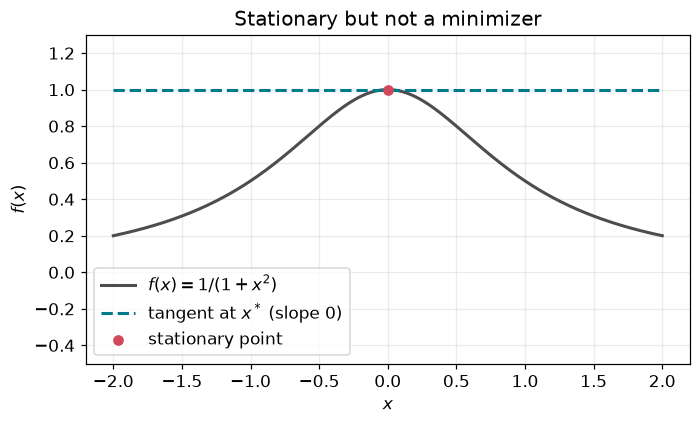

In [4]:
def runge_prime(x):
    return -2 * x / (1 + x**2)**2

x_star = brentq(runge_prime, -0.5, 0.5)
print(f"stationary point: x* = {x_star:.6f},  f'(x*) = {runge_prime(x_star):.2e},  f(x*) = {runge(x_star):.4f}")

xx = np.linspace(-2, 2, 400)
tangent = runge(x_star) + runge_prime(x_star) * (xx - x_star)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(xx, runge(xx), color="0.3", lw=2, label="$f(x)=1/(1+x^2)$")
ax.plot(xx, tangent, color=COLORS["boundary"], lw=2, ls="--", label="tangent at $x^*$ (slope 0)")
ax.scatter([x_star], [runge(x_star)], color=COLORS["optimum"], zorder=3, label="stationary point")
ax.set_ylim(-0.5, 1.3)
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Stationary but not a minimizer")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Multivariate FONC: solving $\nabla f(\mathbf{x})=0$

The same argument in $\mathbb{R}^n$ requires every partial derivative to vanish at a candidate minimizer:

$$
\frac{\partial f(\mathbf{x}^\ast)}{\partial x_i} = 0 \quad \forall i.
$$

For a general (possibly nonlinear) $f$, this is itself a system of nonlinear equations - precisely the kind of unconstrained problem mentioned in the introduction. We solve it with `scipy.optimize.fsolve` on a numerically estimated gradient, for

$$
f(x_1,x_2) = \sin(x_1) + 0.3x_1^2 + (x_2-1)^2.
$$

stationary point: x* = [-0.9582519  1.       ]
gradient there:   [0. 0.]  (should be ~0)
f(x*) = -0.5427


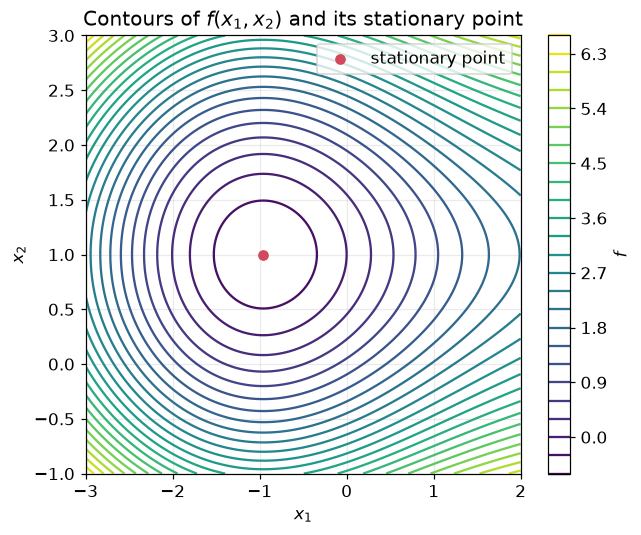

In [5]:
def f2(x):
    x1, x2 = x
    return np.sin(x1) + 0.3 * x1**2 + (x2 - 1)**2

def gradient(func, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = h
        g[i] = (func(x + step) - func(x - step)) / (2 * h)
    return g

x_star2 = fsolve(lambda x: gradient(f2, x), x0=[0.5, 0.5])
print(f"stationary point: x* = {x_star2}")
print(f"gradient there:   {gradient(f2, x_star2)}  (should be ~0)")
print(f"f(x*) = {f2(x_star2):.4f}")

x1, x2 = np.meshgrid(np.linspace(-3, 2, 200), np.linspace(-1, 3, 200))
Z = np.sin(x1) + 0.3 * x1**2 + (x2 - 1)**2
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(x1, x2, Z, levels=25, cmap="viridis")
ax.scatter(*x_star2, color=COLORS["optimum"], zorder=3, label="stationary point")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Contours of $f(x_1,x_2)$ and its stationary point")
plt.colorbar(cs, ax=ax, label="$f$")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Stationary points that are neither minima nor maxima: saddle points

$$
f(x_1,x_2) = x_1^2 - x_2^2
$$

has $\nabla f(0,0)=(0,0)$: it is stationary. But moving away from the origin along $x_2=0$ increases $f$, while moving along $x_1=0$ decreases it. The origin is a **saddle (inflection) point** - this is exactly the picture in the lecture slides.

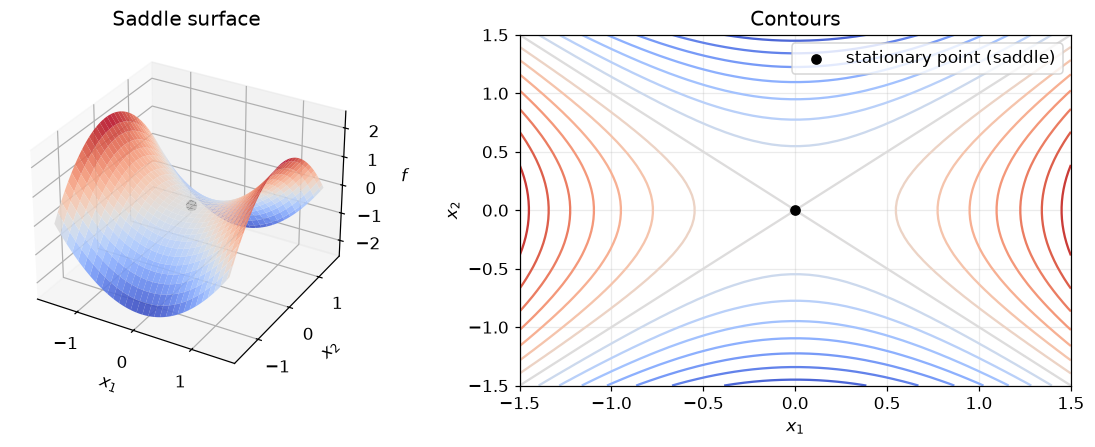

Along x2=0: [0.25 0.   0.25]  -> increases away from 0 (looks like a min)
Along x1=0: [-0.25  0.   -0.25]  -> decreases away from 0 (looks like a max)
Neither direction alone tells the whole story - Hessians (next notebook) resolve this.


In [6]:
def saddle(x1, x2):
    return x1**2 - x2**2

X1, X2 = np.meshgrid(np.linspace(-1.5, 1.5, 60), np.linspace(-1.5, 1.5, 60))
Z = saddle(X1, X2)

fig = plt.figure(figsize=(11, 4.2))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X1, X2, Z, cmap="coolwarm", alpha=0.9, linewidth=0)
ax1.scatter([0], [0], [0], color="black", s=40)
ax1.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="$f$", title="Saddle surface")

ax2 = fig.add_subplot(1, 2, 2)
ax2.contour(X1, X2, Z, levels=15, cmap="coolwarm")
ax2.scatter([0], [0], color="black", zorder=3, label="stationary point (saddle)")
ax2.set(xlabel="$x_1$", ylabel="$x_2$", title="Contours")
ax2.legend()
plt.tight_layout()
plt.show()

print("Along x2=0:", saddle(np.array([-0.5, 0, 0.5]), 0), " -> increases away from 0 (looks like a min)")
print("Along x1=0:", saddle(0, np.array([-0.5, 0, 0.5])), " -> decreases away from 0 (looks like a max)")
print("Neither direction alone tells the whole story - Hessians (next notebook) resolve this.")

---
## 5. Interactive: order of the Taylor approximation

Move the slider to change the truncation order $k$ and the evaluation point, and watch when the approximation is trustworthy (inside the shaded radius of convergence) versus misleading (outside it).

In [7]:
def taylor_demo(k=4, x_eval=1.5):
    xx = np.linspace(-2.2, 2.2, 400)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(xx, runge(xx), color="0.3", lw=2, label="$f(x)$")
    ax.plot(xx, taylor_runge(xx, k), color=COLORS["boundary"], lw=2, label=f"order $k={k}$")
    ax.axvspan(-1, 1, color=COLORS["accent"], alpha=0.15, label="radius of convergence")
    ax.scatter([x_eval], [runge(x_eval)], color="black", zorder=3)
    ax.set_ylim(-3, 3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    approx = taylor_runge(np.array([x_eval]), k)[0]
    print(f"T_{k}({x_eval}) = {approx:.4f}, true f({x_eval}) = {runge(x_eval):.4f}, error = {abs(approx-runge(x_eval)):.4f}")

if WIDGETS_AVAILABLE:
    display(widgets.interactive(taylor_demo,
                                 k=widgets.IntSlider(value=4, min=0, max=20, step=1),
                                 x_eval=widgets.FloatSlider(value=1.5, min=0.1, max=2.0, step=0.1)))
else:
    print("ipywidgets is not installed; running the default case.")
    taylor_demo()

interactive(children=(IntSlider(value=4, description='k', max=20), FloatSlider(value=1.5, description='x_eval'…

---
## Takeaways

1. A Taylor polynomial only has to approximate $f$ well *near* the expansion point; increasing the order does not help (and can hurt) outside the radius of convergence.
2. The FONC $\nabla f(x^\ast)=0$ comes directly from requiring the first-order (tangent) approximation to be consistent with $x^\ast$ being a local minimizer.
3. Finding a stationary point is a root-finding problem on $\nabla f$, solvable the same way whether $f$ is one- or many-dimensional.
4. A stationary point can be a minimizer, a maximizer, or a saddle point - the FONC alone cannot tell these apart; that is the job of the SOSC in the next notebook.

## Optional exercises

1. Repeat the Taylor-polynomial figure for $f(x)=\cos(x)$ expanded at $x^\ast=0$ using its exact Maclaurin coefficients ($1,0,-1/2,0,1/24,\ldots$). Does the polynomial keep improving as $k$ grows, unlike the Runge example? Why?
2. Find all stationary points of $f(x_1,x_2)=x_1^3-3x_1x_2^2$ (the "monkey saddle") using `fsolve` from several starting guesses, and check whether they are unique.
3. For the two-variable example in Section 3, start `fsolve` from several different initial guesses. Does it always find the same stationary point? What does that suggest about how many stationary points $f$ has?